In [36]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


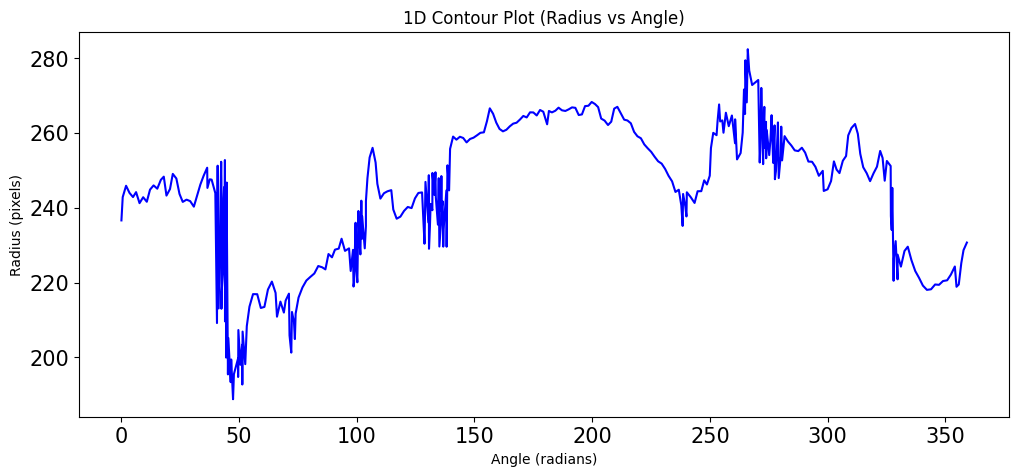

Mininum Radius: 188.851834109081
Maximum Radius: 282.33798060801996
Mean Radius: 243.42865036070313
Median Radius: 246.31627656138016


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from skimage import measure
from scipy.interpolate import splprep, splev
from skimage.transform import rescale
from scipy.ndimage import binary_opening

plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

# Load FITS image
fits_file = "/content/drive/MyDrive/TYCHO_SNR_RESEARCH CAPSTONE_PROJECT/TychoFlux/Band06_Flux.fits"
hdul = fits.open(fits_file)
image_data = hdul[0].data
hdul.close()

# Normalize and resize image
image_data = np.nan_to_num(image_data)
image_data = rescale(image_data, 0.99, anti_aliasing=True)  # Downscale for speed

# It's adjusted to a lower value to detect more contours.
threshold = np.percentile(image_data, 88.5) # Apply threshold (manually tuned)
binary_image = image_data > threshold

# Remove small artifacts
binary_image = binary_opening(binary_image)

# Extract contours
contours = measure.find_contours(binary_image, level=0.5)

# Check if any contours were found
if len(contours) == 0:
    print("No contours found. Try adjusting the threshold value.")
else:
    longest_contour = max(contours, key=len)

    # Downsample contour points to speed up interpolation
    num_points = 360  # Reduce number of points
    indices = np.linspace(0, len(longest_contour) - 1, num_points).astype(int)
    x, y = longest_contour[:, 1][indices], longest_contour[:, 0][indices]

    # Smooth interpolation (increase s for speed)
    tck, u = splprep([x, y], s=10)
    u_fine = np.linspace(0, 1, 360)  # Reduce number of interpolated points
    x_smooth, y_smooth = splev(u_fine, tck)

    # Plot image with smooth contour
    #fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    #ax[0].imshow(image_data, cmap='viridis', origin='lower', vmin=np.percentile(image_data, 50), vmax=np.percentile(image_data, 100))
    #ax[0].plot(x_smooth, y_smooth, color='red', linewidth=2)
    #ax[0].set_title("Supernova with Interpolated Contour")
    #ax[0].set_xlim(950, 2100)
    #ax[0].set_ylim(950, 2100)

    plt.figure(figsize=(12, 5))

    # Compute radius vs. angle
    xc, yc = np.mean(x_smooth), np.mean(y_smooth)
    r = np.sqrt((x_smooth - xc) ** 2 + (y_smooth - yc) ** 2) * 0.492
    theta = np.arctan2(y_smooth - yc, x_smooth - xc)
    theta = np.degrees(theta) + 180


    # Sort by angle for smooth plotting
    sorted_indices = np.argsort(theta)
    theta_sorted, r_sorted = theta[sorted_indices], r[sorted_indices]

    plt.plot(theta_sorted, r_sorted, color='blue')
    plt.title("1D Contour Plot (Radius vs Angle)")
    plt.xlabel("Angle (radians)")
    plt.ylabel("Radius (pixels)")
    #plt.grid(True)

    plt.show()


print(f"Mininum Radius: {np.min(r_sorted)}")
print(f"Maximum Radius: {np.max(r_sorted)}")
print(f"Mean Radius: {np.mean(r_sorted)}")
print(f"Median Radius: {np.median(r_sorted)}")

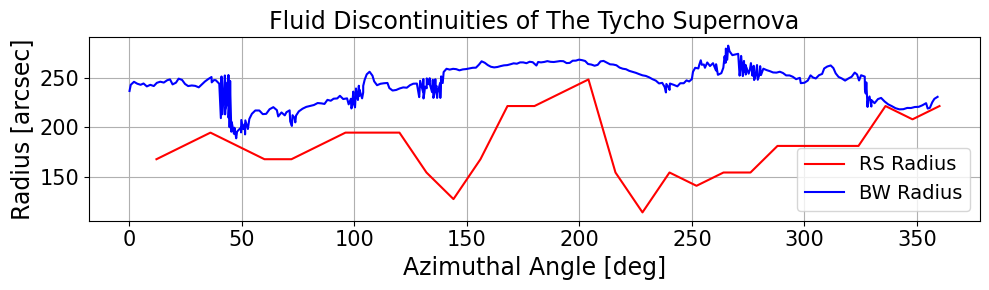

In [67]:
RSRadialProfile_File = '/content/drive/MyDrive/TYCHO_SNR_RESEARCH CAPSTONE_PROJECT/RSRadialProfile.fits'

with fits.open(RSRadialProfile_File, ignore_missing_end=True) as hdu_list:
    hdu_list.verify('silentfix')
    hist_dataReverseShock = hdu_list[1].data

# Grab the radius values
radiusRS = hist_dataReverseShock['RMID']


# Need to convert from pixels to arcsec using plate scale
radiusRS = radiusRS * 0.492


# Grab the angle values
angleRS = hist_dataReverseShock['ROTANG']
angleRS = angleRS[:, 0]


# Grab the counts values given in photons/pixel**2
countsRS = hist_dataReverseShock['SUR_BRI']

radlistRS = []
countslistRS = []

for theta, rad, flux in zip(np.round(angleRS,0), radiusRS, countsRS):
    if theta == 144:
        radlistRS.append(rad)
        countslistRS.append(flux)

# Round angles to avoid floating point issues
rounded_angles = np.round(angleRS[1:31], 2)
radii = radiusRS[::30]
# print(len(radii), radii)

reverse_shock_radii = []
angle_list = []

for i, theta in enumerate(rounded_angles):

    f_vals = countsRS[i::30]
    # print(len(f_vals))

    r_RS = radii[np.argmax(f_vals)]
    reverse_shock_radii.append(r_RS)
    angle_list.append(theta)

# Final arrays
angle_array = np.array(angle_list)
reverse_shock_array = np.array(reverse_shock_radii)


# Plot
plt.figure(figsize=(10, 3))
plt.plot(angle_array, reverse_shock_array, label='RS Radius', color='r')
plt.plot(theta_sorted, r_sorted, color='b', label='BW Radius')
plt.title("Fluid Discontinuities of The Tycho Supernova", fontsize=17)
plt.xlabel("Azimuthal Angle [deg]", fontsize=17)
plt.ylabel("Radius [arcsec]", fontsize=17)
plt.grid(True)
plt.legend(loc='lower right', prop={'size': 14})
plt.tight_layout()
plt.show()